
# Gradient Descent Comparison

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split


In [3]:

df = pd.read_csv('homeprices_banglore.csv')
df.head()

,area,bedrooms,price
0,1056,2,39.07
1,2600,4,120.00
2,1440,3,62.00
3,1521,3,75.00
4,1200,2,51.00


In [4]:
X = df[['area','bedrooms']]
y = df['price']
x_train,x_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()

x_scaled_train = scaler_x.fit_transform(x_train)
x_scaled_test = scaler_x.transform(x_test)

y_scaled_train = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_scaled_test = scaler_y.transform(y_test.values.reshape(-1,1))


## Batch Gradient Descent Implementation

In [5]:

def batch_gradient_descent(X,y,epochs,lr):
    m,n = X.shape
    w = np.ones(n)
    b = 0
    cost_list = []
    
    for i in range(epochs):
        y_pred = np.dot(X,w)+b
        
        w_grad = -(2/m)*(X.T.dot(y-y_pred))
        b_grad = -(2/m)*np.sum(y-y_pred)
        
        w = w - lr*w_grad
        b = b - lr*b_grad
        
        cost = np.mean((y-y_pred)**2)
        cost_list.append(cost)
        
    return w,b,cost_list

w_bgd,b_bgd,cost_bgd = batch_gradient_descent(x_scaled_train,y_scaled_train.flatten(),200,0.01)


## Stochastic Gradient Descent Implementation

In [6]:

def stochastic_gradient_descent(X,y,epochs,lr):
    m,n = X.shape
    w = np.ones(n)
    b = 0
    cost_list = []
    
    for i in range(epochs):
        for j in range(m):
            idx = np.random.randint(m)
            x_i = X[idx]
            y_i = y[idx]
            
            y_pred = np.dot(x_i,w)+b
            
            w_grad = -2*x_i*(y_i-y_pred)
            b_grad = -2*(y_i-y_pred)
            
            w = w - lr*w_grad
            b = b - lr*b_grad
        
        cost = np.mean((y-(np.dot(X,w)+b))**2)
        cost_list.append(cost)
        
    return w,b,cost_list

w_sgd,b_sgd,cost_sgd = stochastic_gradient_descent(x_scaled_train,y_scaled_train.flatten(),200,0.01)


## Mini Batch Gradient Descent Implementation

In [7]:

def mini_batch_gradient_descent(X,y,epochs,lr,batch_size):
    
    m,n = X.shape
    w = np.ones(n)
    b = 0
    cost_list = []
    
    for i in range(epochs):
        
        indices = np.random.permutation(m)
        X_temp = X[indices]
        y_temp = y[indices]
        
        for j in range(0,m,batch_size):
            
            X_batch = X_temp[j:j+batch_size]
            y_batch = y_temp[j:j+batch_size]
            
            y_pred = np.dot(X_batch,w)+b
            
            w_grad = -(2/len(X_batch))*(X_batch.T.dot(y_batch-y_pred))
            b_grad = -(2/len(X_batch))*np.sum(y_batch-y_pred)
            
            w = w - lr*w_grad
            b = b - lr*b_grad
        
        cost = np.mean((y-(np.dot(X,w)+b))**2)
        cost_list.append(cost)
    
    return w,b,cost_list

w_mbgd,b_mbgd,cost_mbgd = mini_batch_gradient_descent(x_scaled_train,y_scaled_train.flatten(),200,0.01,5)


## Cost vs Epoch Comparison

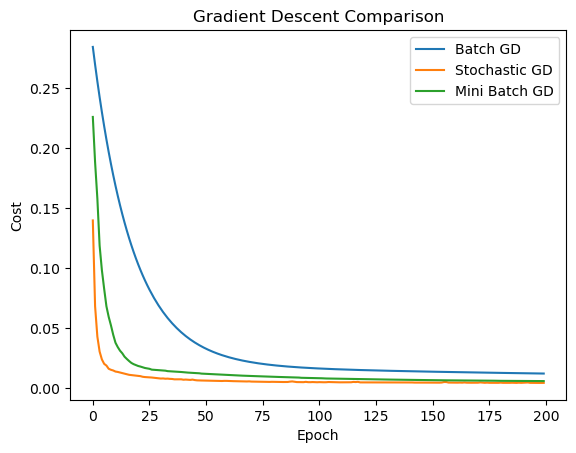

In [8]:

plt.figure()

plt.plot(cost_bgd,label='Batch GD')
plt.plot(cost_sgd,label='Stochastic GD')
plt.plot(cost_mbgd,label='Mini Batch GD')

plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.title("Gradient Descent Comparison")

plt.legend()
plt.show()
